In [1]:
import os
import sys

project_root = '/home/jovyan/project_10x'

sys.path.append(os.path.join(project_root, 'src'))

from utils import *
from sentiment_extraction_MB_10k import *

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/tmp/ipykernel_365/2344385679.py:17: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
def clean_mem():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    time.sleep(0.1)

clean_mem()

In [4]:
sys.version

'3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:43:55) [GCC 13.3.0]'

# Model - ModernBERT

In [10]:
model_id = "/home/jovyan/models-2/ModernBERT-large"

tokenizer = AutoTokenizer.from_pretrained(model_id,
#                                           max_length=length,
                                          padding=True,
                                          truncation=True,
                                          cache_dir="hf_cache")
if not tokenizer.pad_token:
    print("Adding pad token")
    tokenizer.pad_token = tokenizer.eos_token
    
tokenizer.padding_side = "left"

model = AutoModelForMaskedLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, cache_dir="hf_cache"
).to(device)

config = AutoConfig.from_pretrained(model_id)
length = config.max_position_embeddings
length

8192

In [13]:
model.name = 'Llama3_1'

In [14]:
def get_prompt(item_text: str, ending: str) -> str:
    return item_text + "\n\n" + ending 

## Whole dataset

In [15]:
report_path = '/home/jovyan/datavol-2/'

reports = pd.read_csv(os.path.join(report_path, '10k_filtered.tsv.gz'), sep='\t')
reports = reports[['CIK', 'FILING_DATE', 'ACC_NUM']]
reports['CIK'] = reports['CIK'].astype(str)
reports['FILING_DATE'] = reports['FILING_DATE'].astype(str)
reports['ACC_NUM'] = reports['ACC_NUM'].astype(str)
# reports

df = pd.read_sas('/home/jovyan/datavol-2/finaldata_10k.sas7bdat')

df['ACC_NUM'] = df['filename'].astype(str).str.split('_').str[1]
df['CIK'] = df['filename'].astype(str).str.split('_').str[0]
df['FILING_DATE'] = df['date_filed'].astype(str).str.replace('-', '')
# reports = df[df['FILING_DATE'].astype(str).str[:4] < '2013'].reset_index(drop=True)
df = df[['CIK', 'FILING_DATE', 'ACC_NUM']]
df['CIK'] = df['CIK'].astype(str)
df['FILING_DATE'] = df['FILING_DATE'].astype(str)
df['ACC_NUM'] = df['ACC_NUM'].astype(str)
# reports

missing = pd.read_csv('/home/jovyan/datavol-2/missing_item7.tsv.gz', sep='\t')

missing['ACC_NUM'] = missing['name'].astype(str).str.split('_').str[-1]
missing['CIK'] = missing['name'].astype(str).str.split('_').str[-2]
missing['FILING_DATE'] = missing['name'].astype(str).str.split('_').str[0]
missing = missing[['CIK', 'FILING_DATE', 'ACC_NUM']]

In [16]:
res_df = pd.concat([reports, df, missing], axis=0)
res_df = res_df.drop_duplicates().reset_index(drop=True)

res_df.shape, res_df.drop_duplicates().shape

((109921, 3), (109921, 3))

In [17]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109921 entries, 0 to 109920
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   CIK          109921 non-null  object
 1   FILING_DATE  109921 non-null  object
 2   ACC_NUM      109921 non-null  object
dtypes: object(3)
memory usage: 2.5+ MB


In [19]:
res_df

,CIK,FILING_DATE,ACC_NUM
0,1750,20130726,0001047469-13-007797
1,1750,20140717,0001047469-14-006243
2,1750,20150715,0001047469-15-006136
3,1750,20160713,0001047469-16-014299
4,1750,20170712,0001047469-17-004528
...,...,...,...
109916,1634432,20190227,0001558370-19-001146
109917,1638381,20190227,0001213900-19-003211
109918,1489393,20110318,0000950123-11-026580
109919,1489393,20120229,0001193125-12-088192


In [20]:
res_df.to_csv('/home/jovyan/datavol-2/df_whole_sample.csv', index=True)

In [36]:
items_path = '/home/jovyan/datavol-2/items/item7_files'

dataset = Dataset10x(res_df, items_path)
len(dataset)
# 109921

109921

In [38]:
splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(tokenizer=tokenizer,
                                                                     chunk_size=length,
                                                                     chunk_overlap=240)

## Growth Sentiment Extraction

### In one word, we are [MASK] regarding the future growth of our company

In [72]:
ending = "In one word, we are [MASK] regarding the future growth of our company."

In [1]:
idx = 11_900

_, item_dict = dataset[idx]
date = reports.iloc[idx].FILING_DATE
item_text = item_dict.get('item7')[:1000]

In [51]:
prompt = get_prompt(item_text, ending)
probs = get_model_output(prompt, model, device)
probs

input has torch.Size([1, 8192]) tokens


{' optimistic': 0.73046875,
 ' confident': 0.126953125,
 ' excited': 0.0869140625,
 ' enthusiastic': 0.01177978515625,
 ' positive': 0.0091552734375,
 ' hopeful': 0.006317138671875,
 ' concerned': 0.0038299560546875,
 ' encouraged': 0.0029754638671875,
 ' cautious': 0.00180816650390625,
 ' aggressive': 0.00159454345703125,
 ' ambitious': 0.00159454345703125,
 ' realistic': 0.00124359130859375,
 ' uncertain': 0.00124359130859375,
 ' proactive': 0.00090789794921875,
 ' focused': 0.00080108642578125,
 ' serious': 0.00058746337890625,
 ' passionate': 0.00058746337890625,
 ' conservative': 0.00058746337890625,
 ' certain': 0.000457763671875,
 ' strategic': 0.00040435791015625}

In [55]:
clean_mem()

In [62]:
@dataclass(frozen=True)
class Prompt_Strategy:
    name: str
    verbalizer: dict
    prompt: Callable
    top_p: float = 0.99

sentiment_verb = {
    "positive": set(['optimistic', 'confident', 'positive', 'encouraged', 'excited',
                     'enthusiastic', 'hopeful', 'pleased', 'encouraging', 'ambitious',
                     'favorable', 'assured', 'strong', 'good', 'excellent', 'outstanding', 
                     'healthy', 'awesome', 'great', 'fantastic', 'stable',
                     'perfect', 'solid', 'profitable', 'impressive', 'reliable',
                     'thriving', 'optimistic', 'sustainable',
                     'exceptional', 'promising', 'bright', 'attractive',
                     'comfortable', 'satisfied', 'relaxed', 'satisfied', 'comfortable',
                     'ambitious', 'determined', 'bullish', 'upbeat', 'convinced', 
                     'certain', 'reassured',
                     ]),
    
    "negative": set(['cautious', 'concerned', 'pessimistic', 'negative',
                     'uncomfortable', 'uncertain', 'unsure',
                     'skeptical', 'worried', 'worrying', 'discouraged', 
                     'confused', 'doubtful', 'unsatisfied', 'disappointed',
                     'bad', 'poor', 'terrible', 'risky', 'weak', 'dependent',
                     'unstable', 'unhealthy', 'questionable', 'suffering', 'stressed',
                     'unsustainable', 'awful', 'vulnerable',
                     'mediocre', 'horrible', 'precarious', 'declining', 'worsening',
                     'difficult', 'limited', 'challenged', 'disappointed', 'discouraged',
                     'frustrated', 'dissatisfied', 'worried', 'anxious', 'nervous', 'uneasy',
                     'doubtful', 'skeptical', 'apprehensive',
                    ])
}

sentiment_strategy = Prompt_Strategy('sentiment', sentiment_verb, get_prompt)

len(sentiment_verb['positive']), len(sentiment_verb['negative'])

(41, 43)

In [63]:
q99 = 275568
q95 = 169981

In [64]:
batch_size = 2

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=split_collator
)

len(dataloader)

54961

In [69]:
clean_mem()

In [73]:
ending = "In one word, we are [MASK] regarding the future growth of our company."

In [74]:
results = []

In [ ]:
stats_sent = gather_stats(sentiment_strategy, results=results, tokenizer=tokenizer, model=model,
                          data=dataloader, ending=ending, verbose=False, text_length=q99, 
                          save_path="/home/jovyan/datavol-2/sentiments/growth_sentiment_MB/",
                          save_interval=1000, resume=True, max_retries=3, device=device)

  3%|▎         | 1550/54961 [1:30:41<33:22:48,  2.25s/it] 

CUDA OOM error processing batch [3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101] (attempt 1): CUDA out of memory. Tried to allocate 102.99 GiB. GPU 0 has a total capacity of 79.15 GiB of which 72.39 GiB is free. Process 1540581 has 6.75 GiB mem

  3%|▎         | 1551/54961 [1:32:17<451:41:33, 30.45s/it]

CUDA OOM error processing batch [3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3100, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101] (attempt 3): CUDA out of memory. Tried to allocate 102.99 GiB. GPU 0 has a total capacity of 79.15 GiB of which 72.39 GiB is free. Process 1540581 has 6.75 GiB mem

  3%|▎         | 1552/54961 [1:33:53<740:08:41, 49.89s/it]

...

  3%|▎         | 1758/54961 [1:48:17<361:04:45, 24.43s/it]

CUDA OOM error processing batch [3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517] (attempt 1): CUDA out of memory. Tried to allocate 93.00 GiB. GPU 0 has a total capacity of 79.15 GiB of which 72.91 GiB is free. Process 1540581 has 6.23 GiB memory in use. Of the allocated memory 4.54 GiB is allocated by PyTorch, and 1.20 

  3%|▎         | 1759/54961 [1:49:42<612:20:22, 41.43s/it]

CUDA OOM error processing batch [3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3516, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517, 3517] (attempt 3): CUDA out of memory. Tried to allocate 93.00 GiB. GPU 0 has a total capacity of 79.15 GiB of which 72.91 GiB is free. Process 1540581 has 6.23 GiB memory in use. Of the allocated memory 4.54 GiB is allocated by PyTorch, and 1.20 

  7%|▋         | 3587/54961 [3:38:42<54:32:12,  3.82s/it] IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

 35%|███▍      | 19115/54961 [18:49:02<32:09:44,  3.23s/it] 

In [ ]:
clean_mem()

In [ ]:
time.sleep(60)
clean_mem()
torch.cuda.empty_cache()
time.sleep(60)

In [ ]:
stats_sent.to_csv('/home/jovyan/datavol-2/sentiments/growth_sentiment_MB/results_full_growth_MB.csv')

<Axes: >

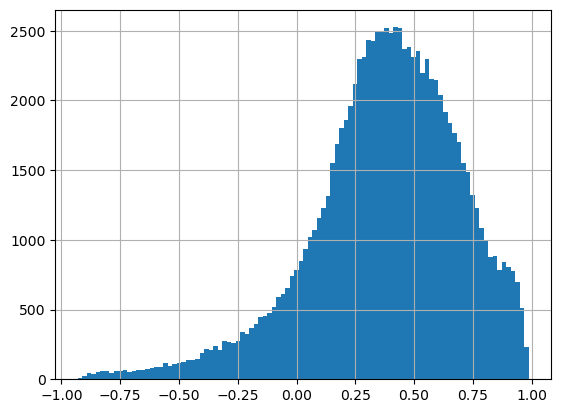

In [81]:
stats_sent['polarity'].hist(bins=100)